# 원본 노트북 링크:
- https://github.com/bcaitech1/p4-fr-sorry-math-but-love-you/tree/master

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/프로젝트/2025 한양대 졸업프로젝트 HMER/OMRiDA 2')

# Utils

- 그동안 imshow할때 aspect="auto"로 했어서 resize shape 관계없이 무조건 정방이미지로 시각화되었는데, resize 어떻게 되었는지 확인할 수 있게 aspect="equal"로 수정하고, 리사이즈 형상에 따라 성능영향차이가 생기는지 실험해보고자 함

In [3]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='equal', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [4]:
import editdistance

def exprate_k(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        if diff<=k:
            cnt += 1

    return cnt / preds.shape[0]


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [5]:
import os
import json
from pathlib import Path

def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [6]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)
- 변경사항: optimizer 옵션을 config에 추가, weight_decay 적용

In [7]:

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(DEVICE)

cuda


In [54]:
import os, json
from datetime import datetime
import torch

epoch = int(input("epoch: "))
patience = int(input("patience: "))
bs = int(input("batch size: "))
optimizer_name = input("optimizer name (AdamW, adadelta, ...): ")

CFG = {
  "img_size": (128,256),
  "pad_idx": 112,
  "sos_idx": 0,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": bs,
    "epochs": epoch,
    "learning_rate": 0.001,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": optimizer_name,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5,
    "early_stop_patience": patience,
  },

  "testing": {"max_len": 150}
}

model_name = "NAVER winner (LiteSATRN) - 128x256 resize, 3 channels"
scheduler_name = input("scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): ")
min_lr = float(input("min_lr: "))
max_lr = float(input("max_lr: "))

experiment_name = f"{model_name}_epoch{CFG['training']['epochs']}_patience_{CFG['training']['early_stop_patience']}_bs{CFG['training']['batch_size']}_scheduler_{scheduler_name}_minLR_{min_lr}_maxLR_{max_lr}"

CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

scheduler_info = {"name": scheduler_name}

CFG["scheduler"] = scheduler_info

epoch: 50
patience: 3
batch size: 16
optimizer name (AdamW, adadelta, ...): adamw
scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): circularlrbeta
min_lr: 5e-4
max_lr: 5e-4


In [55]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/NAVER winner (LiteSATRN) - 128x256 resize, 3 channels_epoch50_patience_3_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/config.json


In [56]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset

## Vocab

In [57]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [58]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [59]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('RGB')#.convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [60]:
train_path = CFG["data"]["crohme"]["hme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

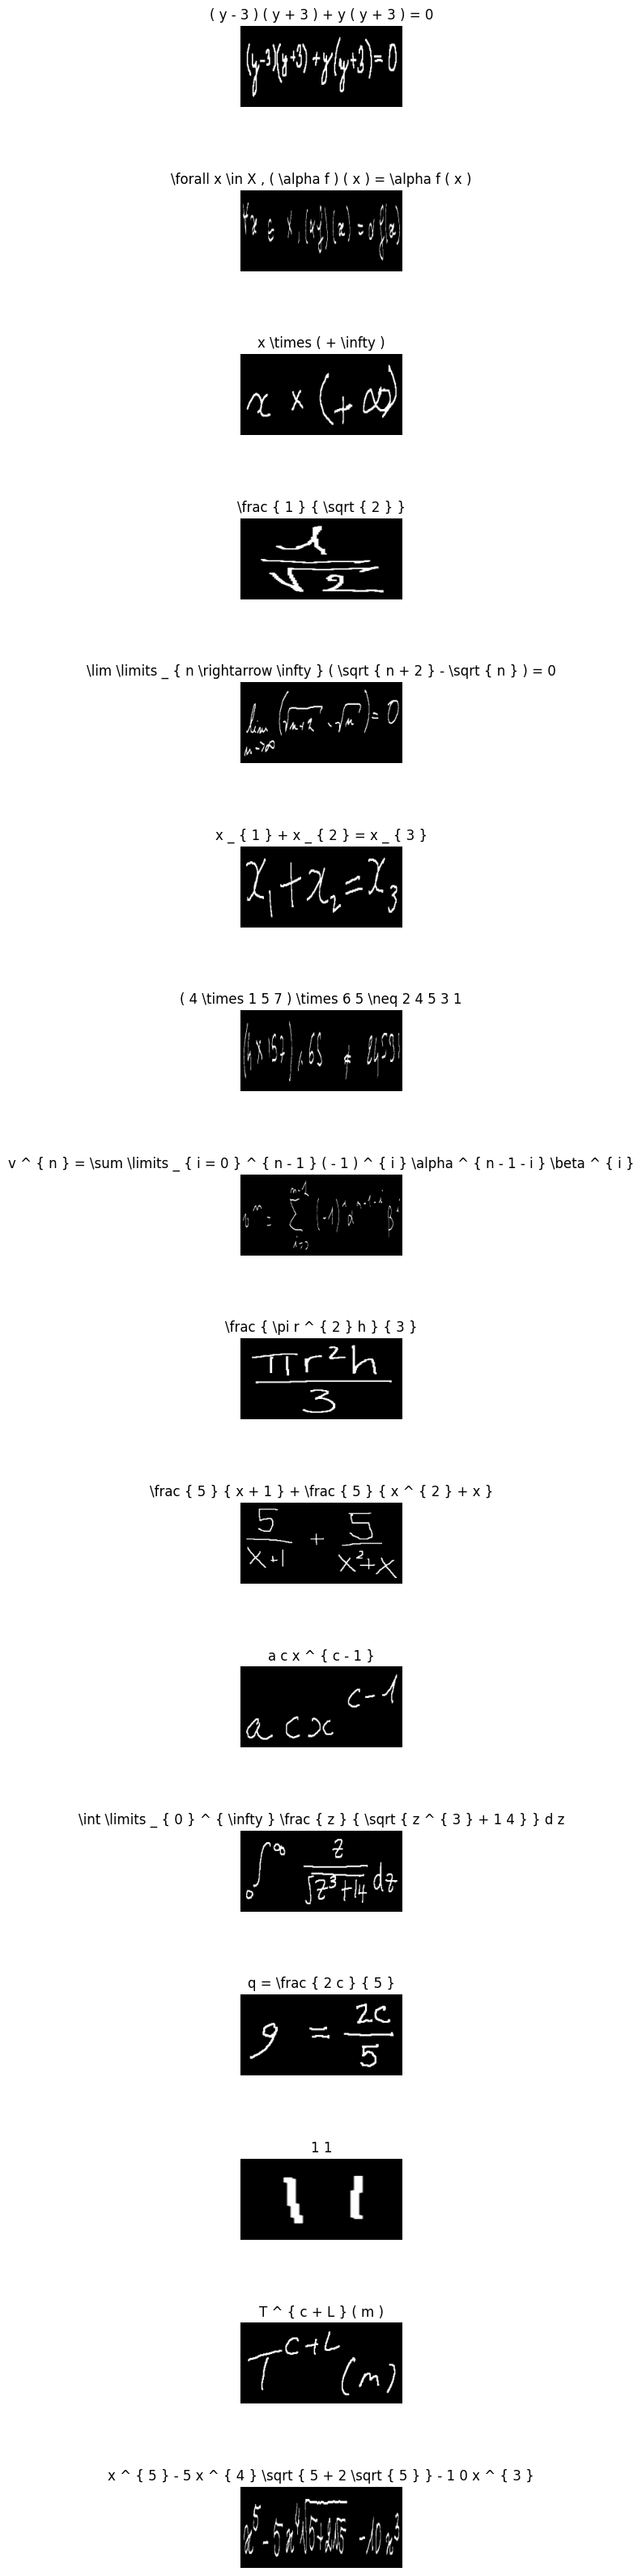

In [61]:
batch_size = CFG["training"]["batch_size"]


# train valid split
trainset = FormulaDataset(train_path, train_labels_path, transform, vocab)
train_size = int(0.8 * len(trainset))
valid_size = len(trainset) - train_size
trainset, validset = torch.utils.data.random_split(trainset,[train_size, valid_size])


# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=formula_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)

im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, transform, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# 데이터 확인

batch = next(iter(trainloader))
images = batch['image']
labels = batch['formula']
plot_dataset(images, labels, grid_width=1, grid_height=bs, figure_width=1, figure_height=bs, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

## LiteSATRN


In [62]:
import torch
from torch.utils.data import DataLoader
from queue import PriorityQueue


def decode(
    model,
    input: torch.Tensor,
    data_loader: DataLoader = None,
    expected: torch.Tensor = None,
    method: str = "greedy",
    beam_width: int = 3,
) -> torch.Tensor:
    """디코딩을 수행하는 함수. NOTE: inference/validation에만 활용!

    Args:
        model (torch.nn.Module):
        input (torch.Tensor): 이미지 input
        data_loader (DataLoader, optional):
            - Beam-Search를 활용할 경우 필요한 argument
            - Defaults to None.
        expected (torch.Tensor, optional):
            - Validation에서 디코딩할 경우 필요한 argument: Validation 단계에서는 max_length를 ground-truth를 바탕으로 설정하기 때문
            - Defaults to None.
        method (str, optional): 디코딩 타입 설정. Defaults to 'greedy'.
            - 'greedy': 그리디 디코딩
            - 'beam': 빔서치
        beam_width (int, optional): 빔서치 활용 시 채택할 beam size. Defaults to 3.

    Returns:
        squence (torch.Tensor): id_to_string에 입력 가능한 output sequence 텐서
    """

    if method == "greedy":
        output = model(
            input=input, expected=expected, is_train=False, teacher_forcing_ratio=0.0
        )
        decoded_values = output.transpose(1, 2)  # [B, VOCAB_SIZE, MAX_LEN]
        _, sequence = torch.topk(decoded_values, 1, dim=1)  # sequence: [B, 1, MAX_LEN]
        sequence = sequence.squeeze(1)  # [B, MAX_LEN], 각 샘플에 대해 시퀀스가 생성 상태

    elif method == "beam":
        sequence = model.beam_search(
            input=input,
            data_loader=data_loader,
            beam_width=beam_width,
            max_sequence=expected.size(-1) - 1,  # expected에는 이미 시작 토큰 개수까지 포함
        )

    else:
        raise NotImplementedError(f"There's no '{method}' type yet.")

    return sequence


class BeamSearchNode(object):
    def __init__(self, hidden_state, prev_node, token_id, log_prob, length):
        self.hidden_state = hidden_state
        self.prev_node = prev_node
        self.token_id = token_id
        self.logp = log_prob
        self.len = length  # 길이

    def eval(self, alpha=0.1) -> float:
        """score 측정 함수
        score: L - 해당 스텝까지의 총 길이, alpha - 페널티항, c: context
            {1/L^{alpha}} * log{ P(y_{1}, ..., y_{L} | c)}
            = {1/L^{alpha}}*SUM_{t'=1}^{L}{log{P(y_{1}, ..., y_{L} | c)}}
        Args:
            alpha (float, optional): 스텝 길이에 따른 페널티를 위한 파라미터. Defaults to 0.75.

        Returns:
            score (float): 점수

        References:
            - Beam Search, Dive into Deep Learning,
              https://d2l.ai/chapter_recurrent-modern/beam-search.html#id1
        """

        return self.logp / (float(self.len))  # **alpha)
        # return self.logp / float(self.len - 1 + 1e-6) + alpha * reward

    def __lt__(self, other):
        return self.len < other.len

    def __gt__(self, other):
        return self.len > other.len

    def get_penalty(self, length, alpha: float = 1.2, min_length: int = 5):
        p = ((1 + length) / (1 + min_length)) ** alpha
        return p

In [63]:
from copy import deepcopy
import math
import random
from queue import PriorityQueue
import operator
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import timm
import sys

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class ShallowCNN(nn.Module):
    def __init__(self, input_channels, hidden_size):
        super(ShallowCNN, self).__init__()
        self.conv0 = nn.Conv2d(
            input_channels, hidden_size // 2, 3, bias=False, padding=1
        )
        self.batch_norm0 = nn.BatchNorm2d(hidden_size // 2)
        self.relu0 = nn.ReLU()
        self.pool0 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv1 = nn.Conv2d(hidden_size // 2, hidden_size, 3, bias=False, padding=1)
        self.batch_norm1 = nn.BatchNorm2d(hidden_size)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(hidden_size, hidden_size, 3, bias=False, padding=1)
        self.batch_norm2 = nn.BatchNorm2d(hidden_size)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(hidden_size, hidden_size, 3, bias=False, padding=1)
        self.batch_norm3 = nn.BatchNorm2d(hidden_size)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        torch.nn.init.xavier_normal_(self.conv0.weight)
        torch.nn.init.xavier_normal_(self.conv1.weight)
        torch.nn.init.xavier_normal_(self.conv2.weight)

    def forward(self, x):
        x = self.conv0(x)
        x = self.batch_norm0(x)
        x = self.relu0(x)
        x = self.pool0(x)

        x = self.conv1(x)
        x = self.batch_norm1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.batch_norm2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.batch_norm3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        return x  # (batch, hidden_size, h/8, w/8)

class PositionalEncoding(nn.Module):
    def __init__(self, hidden_size, h=128, w=128, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        ## hidden_size < h,w면 nan값 출력 -> input channel이 h,w보다 커야함
        self.hidden_size = hidden_size
        self.h_pos_encoding = self.get_position_encoding(h, hidden_size)
        self.w_pos_encoding = self.get_position_encoding(w, hidden_size)

        self.h_pos_encoding = self.h_pos_encoding.unsqueeze(1)
        self.w_pos_encoding = self.w_pos_encoding.unsqueeze(0)

        self.dropout = nn.Dropout(p=dropout)
        self.dense0 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()

        self.dense1 = nn.Linear(hidden_size // 2, hidden_size * 2)
        self.sigmoid = nn.Sigmoid()

        torch.nn.init.xavier_normal_(self.dense0.weight)
        torch.nn.init.xavier_normal_(self.dense1.weight)

    def get_position_encoding(
        self, length, hidden_size, min_timescale=1.0, max_timescale=1.0e4
    ):
        position = torch.arange(length).float()
        num_timescales = [hidden_size // 2]
        log_timescale_incretement = math.log(
            float(max_timescale) / float(min_timescale)
        ) / (torch.FloatTensor(num_timescales) - 1)
        inv_timescales = min_timescale * torch.exp(
            torch.FloatTensor(
                torch.arange(num_timescales[0]) * -log_timescale_incretement
            )
        )
        scaled_time = torch.unsqueeze(position, 1) * torch.unsqueeze(inv_timescales, 0)
        signal = torch.cat((torch.sin(scaled_time), torch.cos(scaled_time)), axis=1)

        return signal

    def tiling(self, arr, b, c, h, w):
        arr_numpy = arr.numpy()
        arr_tile = np.tile(arr_numpy, (b, c, h, w))

        return torch.from_numpy(arr_tile)

    def forward(self, x):
        features = x
        b, c, h, w = x.size()
        h_encoding = self.tiling(self.h_pos_encoding.unsqueeze(0), b, 1, 1, 1).to(
            device
        )
        w_encoding = self.tiling(self.w_pos_encoding.unsqueeze(0), b, 1, 1, 1).to(
            device
        )
        x = torch.mean(x, [2, 3])
        x = self.dense0(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.dense1(x)
        x = self.sigmoid(x)
        x = torch.reshape(x, [-1, 2, 1, self.hidden_size])
        x = x[:, 0:1, :, :] * h_encoding + x[:, 1:2, :, :] * w_encoding
        x = x.permute(0, 3, 1, 2)
        return x + features  # (batch, hidden_size, h, w)


class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, dropout=0.1):
        super(ScaledDotProductAttention, self).__init__()

        self.temperature = temperature
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, q, k, v, mask=None):

        attn = torch.matmul(q, k.transpose(2, 3)) / self.temperature # [B, 4, 2048, 2048]
        if mask is not None:
            attn = attn.masked_fill(mask=mask, value=float("-inf"))
        attn = torch.softmax(attn, dim=-1)
        attn = self.dropout(attn) # [B, 4, 2048, 2048]
        out = torch.matmul(attn, v) # [B, 4, 2048, 96]
        return out, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, q_channels, k_channels, head_num=8, dropout=0.1):
        super(MultiHeadAttention, self).__init__()

        self.q_channels = q_channels
        self.k_channels = k_channels
        self.head_dim = q_channels // head_num
        self.head_num = head_num

        self.q_linear = nn.Linear(q_channels, self.head_num * self.head_dim)
        self.k_linear = nn.Linear(k_channels, self.head_num * self.head_dim)
        self.v_linear = nn.Linear(k_channels, self.head_num * self.head_dim)
        self.attention = ScaledDotProductAttention(
            temperature=(self.head_num * self.head_dim) ** 0.5, dropout=dropout
        )
        self.out_linear = nn.Linear(self.head_num * self.head_dim, q_channels)
        self.dropout = nn.Dropout(p=dropout)

        torch.nn.init.xavier_normal_(self.q_linear.weight)
        torch.nn.init.xavier_normal_(self.k_linear.weight)
        torch.nn.init.xavier_normal_(self.v_linear.weight)
        torch.nn.init.xavier_normal_(self.out_linear.weight)

    def forward(self, q, k, v, mask=None):
        b, q_len, k_len, v_len = q.size(0), q.size(1), k.size(1), v.size(1)
        q = (
            self.q_linear(q) # [B, 2048, 384]
            .view(b, q_len, self.head_num, self.head_dim) # [B, 2048, 4, 96]
            .transpose(1, 2) # [B, 4, 2048, 96]
        )
        k = (
            self.k_linear(k) # [B, 2048, 384]
            .view(b, k_len, self.head_num, self.head_dim)
            .transpose(1, 2)
        ) # [B, 4, 2048, 96]
        v = (
            self.v_linear(v) # [B, 2048, 384]
            .view(b, v_len, self.head_num, self.head_dim)
            .transpose(1, 2)
        ) # [B, 4, 2048, 96]

        if mask is not None:
            mask = mask.unsqueeze(1)

        out, attn = self.attention(q, k, v, mask=mask)
        out = (
            out.transpose(1, 2)
            .contiguous()
            .view(b, q_len, self.head_num * self.head_dim)
        ) # [B, 2048, 384]
        out = self.out_linear(out) # [B, 2048, 384]
        out = self.dropout(out)

        return out


class EncoderLayer(nn.Module):
    def __init__(self, hidden_size, filter_size, head_num, dropout_rate=0.2):
        super(EncoderLayer, self).__init__()

        self.norm = nn.LayerNorm(hidden_size)
        self.attention_layer = MultiHeadAttention(
            q_channels=hidden_size,
            k_channels=hidden_size,
            head_num=head_num,
            dropout=dropout_rate,
        )
        self.dropout0 = nn.Dropout(dropout_rate)
        self.conv0 = nn.Conv2d(hidden_size, filter_size, 1, bias=False)
        self.norm0 = nn.BatchNorm2d(filter_size)
        self.depthwise = nn.Conv2d(
            filter_size, filter_size, kernel_size=3, padding=1, groups=filter_size
        )
        self.depthwise_norm = nn.BatchNorm2d(filter_size)
        self.conv1 = nn.Conv2d(filter_size, hidden_size, 1, bias=False)
        self.norm1 = nn.BatchNorm2d(hidden_size)
        self.relu0 = nn.ReLU()
        self.relu_depth = nn.ReLU()
        self.relu1 = nn.ReLU()

        torch.nn.init.xavier_normal_(self.conv0.weight)
        torch.nn.init.xavier_normal_(self.depthwise.weight)
        torch.nn.init.xavier_normal_(self.conv1.weight)

    def forward(self, x):
        features = x
        b, c, h, w = x.size()
        x = x.view(b, c, h * w).transpose(1, 2)
        flattend_features = x

        x = self.norm(x)
        x = self.attention_layer(x, x, x)
        x = self.dropout0(x)
        x = self.norm(x + flattend_features) # [B, 2048, 384]
        x = x.reshape(-1, c, h, w) # [B, 384, 32, 64]

        x = self.conv0(x)
        x = self.norm0(x)
        x = self.relu0(x)
        x = self.depthwise(x)
        x = self.depthwise_norm(x)
        x = self.relu_depth(x)
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.relu1(x)

        return x + features  # (batch, hidden_size, h, w)


class SATRNEncoder(nn.Module):
    def __init__(
        self,
        input_height,
        input_width,
        input_channel,
        hidden_size,
        filter_size,
        head_num,
        layer_num,
        dropout_rate=0.1
    ):
        super(SATRNEncoder, self).__init__()
        self.shallow_cnn = ShallowCNN(input_channel, hidden_size)
        self.positional_encoding = PositionalEncoding(
            hidden_size, h=input_height // 16, w=input_width // 16, dropout=dropout_rate
        )
        self.attention_layers = nn.ModuleList(
            [
                EncoderLayer(hidden_size, filter_size, head_num, dropout_rate)
                for _ in range(layer_num)
            ]
        )

    def forward(self, x):
        out = self.shallow_cnn(x) # [B, HIDDEN, 32, 64]
        out = self.positional_encoding(out) # [B, HIDDEN, 32, 64]

        for layer in self.attention_layers:
            out = layer(out) # [B, HIDDEN, 32, 64]

        # flatten
        b, c, h, w = out.size()
        out = out.view(b, c, h * w).transpose(1, 2)  # [b, h x w, c]

        return out  # 4, 128, 512


class Feedforward(nn.Module):
    def __init__(self, filter_size=2048, hidden_dim=512, dropout=0.1):
        super(Feedforward, self).__init__()
        self.linear0 = nn.Linear(hidden_dim, filter_size, True)
        self.relu0 = nn.ReLU()
        self.dropout0 = nn.Dropout(p=dropout)
        self.linear1 = nn.Linear(filter_size, hidden_dim, True)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=dropout)

        torch.nn.init.xavier_normal_(self.linear0.weight)
        torch.nn.init.xavier_normal_(self.linear1.weight)

    def forward(self, input):
        x = self.linear0(input)
        x = self.relu0(x)
        x = self.dropout0(x)
        x = self.linear1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        return x


class TransformerDecoderLayer(nn.Module):
    def __init__(self, input_size, src_size, filter_size, head_num, dropout_rate=0.2):
        super(TransformerDecoderLayer, self).__init__()

        self.self_attention_layer = MultiHeadAttention(
            q_channels=input_size,
            k_channels=input_size,
            head_num=head_num,
            dropout=dropout_rate,
        )
        self.self_attention_norm = nn.LayerNorm(normalized_shape=input_size)

        self.attention_layer = MultiHeadAttention(
            q_channels=input_size,
            k_channels=src_size,
            head_num=head_num,
            dropout=dropout_rate,
        )
        self.attention_norm = nn.LayerNorm(normalized_shape=input_size)

        self.feedforward_layer = Feedforward(
            filter_size=filter_size, hidden_dim=input_size
        )
        self.feedforward_norm = nn.LayerNorm(normalized_shape=input_size)

    def forward(self, tgt, tgt_prev, src, tgt_mask):

        if tgt_prev == None:  # Train
            att = self.self_attention_layer(tgt, tgt, tgt, tgt_mask)
            out = self.self_attention_norm(att + tgt) # DEC [B, 1, HIDDEN]

            att = self.attention_layer(out, src, src)
            out = self.attention_norm(att + out)

            ff = self.feedforward_layer(out)
            out = self.feedforward_norm(ff + out)
        else:
            tgt_prev = torch.cat([tgt_prev, tgt], 1)
            att = self.self_attention_layer(tgt, tgt_prev, tgt_prev, tgt_mask)
            out = self.self_attention_norm(att + tgt)

            att = self.attention_layer(out, src, src)
            out = self.attention_norm(att + out)

            ff = self.feedforward_layer(out)
            out = self.feedforward_norm(ff + out)
        return out


class PositionEncoder1D(nn.Module):
    def __init__(self, in_channels, max_len=500, dropout=0.1):
        super(PositionEncoder1D, self).__init__()

        self.position_encoder = self.generate_encoder(in_channels, max_len)
        self.position_encoder = self.position_encoder.unsqueeze(0)
        self.dropout = nn.Dropout(p=dropout)

    def generate_encoder(self, in_channels, max_len):
        pos = torch.arange(max_len).float().unsqueeze(1)

        i = torch.arange(in_channels).float().unsqueeze(0)
        angle_rates = 1 / torch.pow(10000, (2 * (i // 2)) / in_channels)

        position_encoder = pos * angle_rates
        position_encoder[:, 0::2] = torch.sin(position_encoder[:, 0::2])
        position_encoder[:, 1::2] = torch.cos(position_encoder[:, 1::2])

        return position_encoder

    def forward(self, x, point=-1):
        if point == -1:
            out = x + self.position_encoder[:, : x.size(1), :].to(x.get_device())
            out = self.dropout(out)
        else:
            out = x + self.position_encoder[:, point, :].unsqueeze(1).to(x.get_device())
        return out


class SATRNDecoder(nn.Module):
    def __init__(
        self,
        num_classes,
        src_dim,
        hidden_dim,
        filter_dim,
        head_num,
        dropout_rate,
        pad_id,
        st_id,
        layer_num=1,
        decoding_manager=None,
    ):
        super(SATRNDecoder, self).__init__()
        self.embedding = nn.Embedding(num_classes + 1, hidden_dim)
        self.hidden_dim = hidden_dim
        self.filter_dim = filter_dim
        self.num_classes = num_classes
        self.layer_num = layer_num
        self.pos_encoder = PositionEncoder1D(
            in_channels=hidden_dim, dropout=dropout_rate
        )
        self.attention_layers = nn.ModuleList(
            [
                TransformerDecoderLayer(
                    hidden_dim, src_dim, filter_dim, head_num, dropout_rate
                )
                for _ in range(layer_num)
            ]
        )
        self.generator = nn.Linear(hidden_dim, num_classes)
        self.pad_id = pad_id
        self.st_id = st_id
        self.manager = decoding_manager


    def pad_mask(self, text):
        pad_mask = text == self.pad_id
        pad_mask[:, 0] = False
        pad_mask = pad_mask.unsqueeze(1)
        return pad_mask

    def order_mask(self, length):
        order_mask = torch.triu(torch.ones(length, length), diagonal=1).bool()
        order_mask = order_mask.unsqueeze(0).to(device)
        return order_mask

    def text_embedding(self, texts):
        tgt = self.embedding(texts)
        tgt *= math.sqrt(tgt.size(2))
        return tgt

    def forward(
        self, src, text, is_train=True, batch_max_length=50, teacher_forcing_ratio=1.0
    ):
        if is_train:
            if random.random() < teacher_forcing_ratio:
                tgt = self.text_embedding(text)
                tgt = self.pos_encoder(tgt)
                tgt_mask = self.pad_mask(text) | self.order_mask(text.size(1))
                for layer in self.attention_layers:
                    tgt = layer(tgt, None, src, tgt_mask)
                out = self.generator(tgt)
            else:
                out = []
                num_steps = batch_max_length - 1
                target = (
                    torch.LongTensor(src.size(0)).fill_(self.st_id).to(device)
                )  # [START] token
                features = [None] * self.layer_num

                for t in range(num_steps):
                    target = target.unsqueeze(1) # [16, 1]
                    tgt = self.text_embedding(target) # [16, 1, HIDDEN]
                    tgt = self.pos_encoder(tgt, point=t) # [16, 1, HIDDEN]
                    tgt_mask = self.order_mask(t + 1)
                    tgt_mask = tgt_mask[:, -1].unsqueeze(1)  # [1, (l+1)]
                    for l, layer in enumerate(self.attention_layers):
                        tgt = layer(tgt, features[l], src, tgt_mask)
                        features[l] = (
                            tgt
                            if features[l] == None
                            else torch.cat([features[l], tgt], 1)
                        )
                    _out = self.generator(tgt)  # [b, 1, c]
                    target = torch.argmax(_out[:, -1:, :], dim=-1)  # [b, 1]
                    target = target.squeeze(1)  # [b]
                    out.append(_out)

                out = torch.stack(out, dim=1).to(
                    device
                )  # [b, max length, 1, class length]
                out = out.squeeze(2)  # [b, max length, class length]

        # inference
        else:
            out = []
            num_steps = batch_max_length - 1
            target = (
                torch.LongTensor(src.size(0)).fill_(self.st_id).to(device)
            )  # [START] token
            features = [None] * self.layer_num

            if self.manager is not None:
                self.manager.reset(sequence_length=num_steps)

            for t in range(num_steps):
                target = target.unsqueeze(1)
                tgt = self.text_embedding(target)
                tgt = self.pos_encoder(tgt, point=t)
                tgt_mask = self.order_mask(t + 1)
                tgt_mask = tgt_mask[:, -1].unsqueeze(1)  # [1, (l+1)]
                for l, layer in enumerate(self.attention_layers):
                    tgt = layer(tgt, features[l], src, tgt_mask)
                    features[l] = (
                        tgt if features[l] == None else torch.cat([features[l], tgt], 1)
                    )

                _out = self.generator(tgt)  # [b, 1, c]

                if self.manager is not None:
                    target, _out = self.manager.sift(_out[:, -1:, :])
                else:
                    target = torch.argmax(_out[:, -1:, :], dim=-1)  # [b, 1]
                    target = target.squeeze(1)  # [b]
                out.append(_out)

            out = torch.stack(out, dim=1).to(device)  # [b, max length, 1, class length]
            out = out.squeeze(2)  # [b, max length, class length]

            if self.manager is not None:
                self.manager.reset()

        return out


class LiteSATRN(nn.Module):
    def __init__(self, decoding_manager=None):
        super(LiteSATRN, self).__init__()
        self.encoder = SATRNEncoder(
            input_height=128,
            input_width=256,
            input_channel=3,
            hidden_size=256,
            filter_size=256,
            head_num=4,
            layer_num=1,
            dropout_rate=0.1,
        )

        self.decoder = SATRNDecoder(
            num_classes=CFG["model"]["vocab_size"],
            src_dim=256,
            hidden_dim=128,
            filter_dim=512,
            head_num=4,
            dropout_rate=0.1,
            pad_id=CFG["pad_idx"],
            st_id=CFG["sos_idx"],
            layer_num=2,
            decoding_manager=decoding_manager,
        )
        self.criterion = nn.CrossEntropyLoss(
            ignore_index=CFG["pad_idx"]
        )


    def forward(self, input, expected, is_train, teacher_forcing_ratio):
        enc_result = self.encoder(input) # [B, HxW=2048, HIDDEN]
        dec_result = self.decoder(
            src=enc_result,
            text=expected[:, :-1],
            is_train=is_train,
            batch_max_length=expected.size(1),
            teacher_forcing_ratio=teacher_forcing_ratio,
        )
        return dec_result

# Train


In [64]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    try:
        for epoch in range(1, EPOCHS+1):
            model.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0
            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels, is_train=True, teacher_forcing_ratio=CFG["training"]["tf_ratio"])  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                total_expr_1 += float(expr_1)
                total_expr_2 += float(expr_2)
                total_expr_3 += float(expr_3)
                total_wer += float(wer)
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                if scheduler is not None:
                    scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            # if scheduler:
            #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            #         scheduler.step(avg_loss)
            #     else:
            #         scheduler.step()



            # validation
            model.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

                expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
                expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
                expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
                expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
                wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

                total_loss += float(loss.item())
                total_expr_0 += expr_0
                total_expr_1 += expr_1
                total_expr_2 += expr_2
                total_expr_3 += expr_3
                total_wer += wer
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })

            torch.save({"model": model.state_dict()}, save_last)

            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()

    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"model": model.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

In [65]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        total_wer = 0.0
        num_batches = 0
        lr_history = []

        loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:
            optimizer.zero_grad()

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels, is_train=True, teacher_forcing_ratio=CFG["training"]["tf_ratio"])  # (B,T-1,V)
            labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

            loss.backward()

            if GRAD_CLIP and GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            optimizer.step()

            with torch.no_grad():
                expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

            total_loss += float(loss.item())
            total_expr_0 += float(expr_0)
            total_expr_1 += float(expr_1)
            total_expr_2 += float(expr_2)
            total_expr_3 += float(expr_3)
            total_wer += float(wer)
            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

            if scheduler is not None:
                scheduler.step()

            lr_history.append(optimizer.param_groups[0]['lr'])

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / num_batches
        avg_expr_2 = total_expr_2 / num_batches
        avg_expr_3 = total_expr_3 / num_batches
        avg_wer = total_wer / num_batches


        print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
            f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

        log_dict["Train"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
            "wer": avg_wer,
            "lr": lr_history
        })

        # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
        # if scheduler:
        #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        #         scheduler.step(avg_loss)
        #     else:
        #         scheduler.step()



        # validation
        model.eval()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        total_wer = 0.0
        num_batches = 0

        loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
            labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

            expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
            expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
            expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
            expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
            wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

            total_loss += float(loss.item())
            total_expr_0 += expr_0
            total_expr_1 += expr_1
            total_expr_2 += expr_2
            total_expr_3 += expr_3
            total_wer += wer
            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / num_batches
        avg_expr_2 = total_expr_2 / num_batches
        avg_expr_3 = total_expr_3 / num_batches
        avg_wer = total_wer / num_batches


        print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
            f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

        log_dict["Valid"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
            "wer": avg_wer
        })

        torch.save({"model": model.state_dict()}, save_last)

        if epoch == 1 or avg_loss < best_loss:
            best_loss = avg_loss
            patience = 0
            save_best.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model": model.state_dict()}, save_best)
            print("Best model saved.")

        else:
            patience += 1
            print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
            if patience >= CFG["training"]["early_stop_patience"]:
                print(f"Early stopping at epoch {epoch}")
                break

        print()


    return log_dict, best_loss

# Scheduler

In [66]:
class CircularLRBeta:

    def __init__(
        self, optimizer, lr_max, lr_divider, cut_point, step_size, momentum=None
    ):
        self.lr_max = lr_max
        self.lr_divider = lr_divider
        self.cut_point = step_size // cut_point
        self.step_size = step_size
        self.iteration = 0
        self.cycle_step = int(step_size * (1 - cut_point / 100) / 2)
        self.momentum = momentum
        self.optimizer = optimizer

    def get_lr(self):
        if self.iteration > 2 * self.cycle_step:
            cut = (self.iteration - 2 * self.cycle_step) / (
                self.step_size - 2 * self.cycle_step
            )
            lr = self.lr_max * (1 + (cut * (1 - 100) / 100)) / self.lr_divider

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        else:
            cut = self.iteration / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        return lr

    def get_momentum(self):
        if self.iteration > 2 * self.cycle_step:
            momentum = self.momentum[0]

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        else:
            cut = self.iteration / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        return momentum

    def step(self):
        lr = self.get_lr()

        if self.momentum is not None:
            momentum = self.get_momentum()

        self.iteration += 1

        if self.iteration == self.step_size:
            self.iteration = 0

        for group in self.optimizer.param_groups:
            group['lr'] = lr

            if self.momentum is not None:
                group['betas'] = (momentum, group['betas'][1])

        return lr

In [67]:
# Cosine Annealing with Warmup Scheduler (SGDR)

!pip install 'git+https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup' -q

from cosine_annealing_warmup import CosineAnnealingWarmupRestarts

  Preparing metadata (setup.py) ... done


In [68]:
# @title
# # @title
# # https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup 구현 내용

# import math
# import torch
# from torch.optim.lr_scheduler import _LRScheduler

# class CosineAnnealingWarmupRestarts(_LRScheduler):
#     """
#         optimizer (Optimizer): Wrapped optimizer.
#         first_cycle_steps (int): First cycle step size.
#         cycle_mult(float): Cycle steps magnification. Default: -1.
#         max_lr(float): First cycle's max learning rate. Default: 0.1.
#         min_lr(float): Min learning rate. Default: 0.001.
#         warmup_steps(int): Linear warmup step size. Default: 0.
#         gamma(float): Decrease rate of max learning rate by cycle. Default: 1.
#         last_epoch (int): The index of last epoch. Default: -1.
#     """

#     def __init__(self,
#                  optimizer : torch.optim.Optimizer,
#                  first_cycle_steps : int,
#                  cycle_mult : float = 1.,
#                  max_lr : float = 0.1,
#                  min_lr : float = 0.001,
#                  warmup_steps : int = 0,
#                  gamma : float = 1.,
#                  last_epoch : int = -1
#         ):
#         assert warmup_steps < first_cycle_steps

#         self.first_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle_mult = cycle_mult # cycle steps magnification
#         self.base_max_lr = max_lr # first max learning rate
#         self.max_lr = max_lr # max learning rate in the current cycle
#         self.min_lr = min_lr # min learning rate
#         self.warmup_steps = warmup_steps # warmup step size
#         self.gamma = gamma # decrease rate of max learning rate by cycle

#         self.cur_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle = 0 # cycle count
#         self.step_in_cycle = last_epoch # step size of the current cycle

#         super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

#         # set learning rate min_lr
#         self.init_lr()

#     def init_lr(self):
#         self.base_lrs = []
#         for param_group in self.optimizer.param_groups:
#             param_group['lr'] = self.min_lr
#             self.base_lrs.append(self.min_lr)

#     def get_lr(self):
#         if self.step_in_cycle == -1:
#             return self.base_lrs
#         elif self.step_in_cycle < self.warmup_steps:
#             return [(self.max_lr - base_lr)*self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
#         else:
#             return [base_lr + (self.max_lr - base_lr) \
#                     * (1 + math.cos(math.pi * (self.step_in_cycle-self.warmup_steps) \
#                                     / (self.cur_cycle_steps - self.warmup_steps))) / 2
#                     for base_lr in self.base_lrs]

#     def step(self, epoch=None):
#         if epoch is None:
#             epoch = self.last_epoch + 1
#             self.step_in_cycle = self.step_in_cycle + 1
#             if self.step_in_cycle >= self.cur_cycle_steps:
#                 self.cycle += 1
#                 self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
#                 self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps
#         else:
#             if epoch >= self.first_cycle_steps:
#                 if self.cycle_mult == 1.:
#                     self.step_in_cycle = epoch % self.first_cycle_steps
#                     self.cycle = epoch // self.first_cycle_steps
#                 else:
#                     n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
#                     self.cycle = n
#                     self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
#                     self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)
#             else:
#                 self.cur_cycle_steps = self.first_cycle_steps
#                 self.step_in_cycle = epoch

#         self.max_lr = self.base_max_lr * (self.gamma**self.cycle)
#         self.last_epoch = math.floor(epoch)
#         for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
#             param_group['lr'] = lr

In [69]:
steps = len(trainloader)

params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": steps*epoch,  # 약 20에포크
                                        "cycle_mult": 1.0,
                                        "max_lr": max_lr,
                                        "min_lr": min_lr,
                                        "warmup_steps": steps*epoch*0.1,  # 약 2에포크
                                        "gamma": 1.0
                                        }
CFG["scheduler"]["params"] = params_cosineAnnealingWarmupRestarts

In [70]:
import os, json, random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Vocab
vocab = Vocab()
vocab.load_from_txt("vocab.txt")
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
model = LiteSATRN().to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
weight_decay = CFG["training"].get("weight_decay", 1e-4)
params = model.parameters()

if opt_name == "adam" or opt_name == "adamw":
    optimizer = torch.optim.AdamW(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9, weight_decay=weight_decay)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


scheduler_name = CFG["scheduler"]["name"].lower()

if scheduler_name == "cosineannealingwarmup":
    scheduler = CosineAnnealingWarmupRestarts(optimizer,
                     first_cycle_steps=CFG["scheduler"]["params"]["first_cycle_steps"],
                     cycle_mult=CFG["scheduler"]["params"]["cycle_mult"],
                     max_lr=CFG["scheduler"]["params"]["max_lr"],
                     min_lr=CFG["scheduler"]["params"]["min_lr"],
                     warmup_steps=CFG["scheduler"]["params"]["warmup_steps"],
                     gamma=CFG["scheduler"]["params"]["gamma"])


# 주의 - circularlrbeta 중 하이퍼파라미터에 모멘텀 넣는 경우, param_groups에서 betas가지는 optimizer를 사용해야함 (adadelta는 모멘텀 없으므로 에러발생하는듯)
elif scheduler_name == "circularlrbeta":
    scheduler = CircularLRBeta(optimizer,
                     lr_max=CFG["scheduler"]["params"]["max_lr"],
                     lr_divider=10,           # 최소 학습률 = lr_max / lr_divider로 계산
                     cut_point=10,            # tail 비율을 정해줌 (전체 step 중 tail이전에는 상승->하강 순서로 학습률 변화, 마지막 10%는 lr_min보다 약간 더 감소; 커스텀스케줄러 수식보면 어떤비율만큼 추가 감소시키는지 확인가능)
                     step_size=len(trainloader)*CFG["training"]["epochs"],
                     momentum=[0.95,0.85])    # 최대모멘텀, 최소모멘텀 (모멘텀은 하강->상승->유지 과정거치며 변화)


# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

[Train] Epoch 1/50: 100%|██████████| 442/442 [02:35<00:00,  2.84it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.38, lr=6.99e-5, wer=3.28]



[Train Epoch 1] Loss: 3.4573, Expr@0: 0.0000, Expr@1: 0.0455, Expr@2: 0.0769, Expr@3: 0.1243, WER: 2.1626


[Valid] Epoch 1/50: 100%|██████████| 1767/1767 [02:06<00:00, 13.98it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=4.25, wer=1]



[Valid Epoch 1] Loss: 3.4437, Expr@0: 0.0023, Expr@1: 0.0532, Expr@2: 0.0849, Expr@3: 0.1437, WER: 0.8926
Best model saved.



[Train] Epoch 2/50: 100%|██████████| 442/442 [02:35<00:00,  2.84it/s, expr0=0, expr1=0, expr2=0.0909, expr3=0.0909, loss=2.51, lr=8.99e-5, wer=0.749]


...


[Valid Epoch 27] Loss: 2.2289, Expr@0: 0.0498, Expr@1: 0.1370, Expr@2: 0.2134, Expr@3: 0.2886, WER: 0.5751
Early Stopping count: 2/3



[Train] Epoch 28/50: 100%|██████████| 442/442 [02:32<00:00,  2.89it/s, expr0=0.364, expr1=0.636, expr2=0.636, expr3=0.636, loss=0.519, lr=0.00039, wer=0.489]



[Train Epoch 28] Loss: 1.2156, Expr@0: 0.1691, Expr@1: 0.3274, Expr@2: 0.4346, Expr@3: 0.5125, WER: 0.3757


[Valid] Epoch 28/50: 100%|██████████| 1767/1767 [02:07<00:00, 13.89it/s, expr0=0, expr1=0, expr2=1, expr3=1, loss=1.8, wer=0.5]



[Valid Epoch 28] Loss: 2.2598, Expr@0: 0.0379, Expr@1: 0.1347, Expr@2: 0.2241, Expr@3: 0.3056, WER: 0.5781
Early Stopping count: 3/3
Early stopping at epoch 28


In [71]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/NAVER winner (LiteSATRN) - 128x256 resize, 3 channels_epoch50_patience_3_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/train_log.json


In [72]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

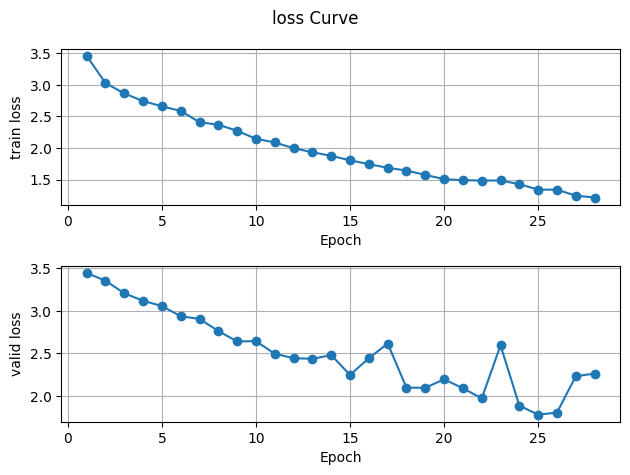

In [73]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

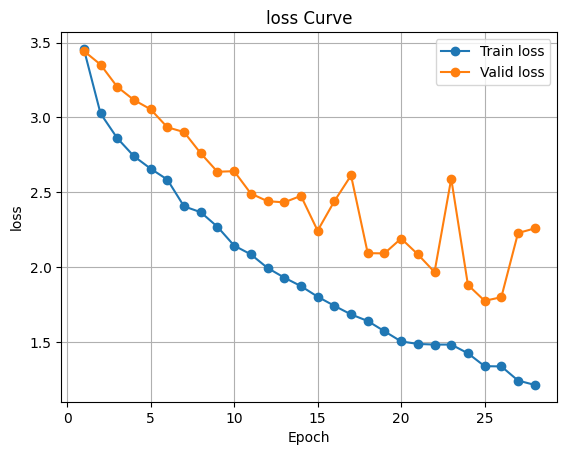

In [74]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

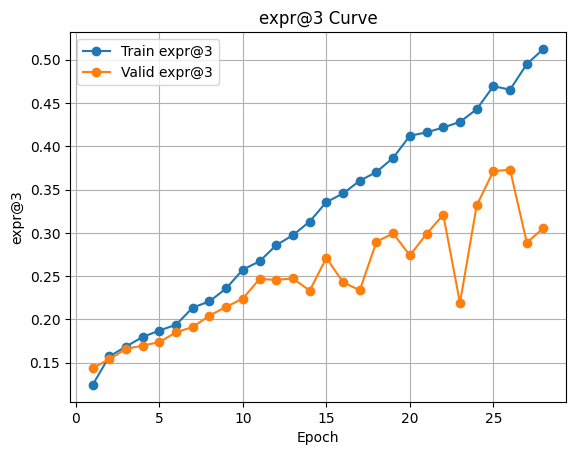

In [75]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

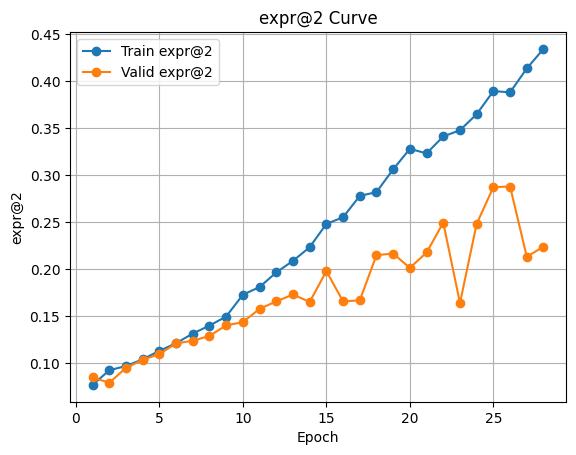

In [76]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

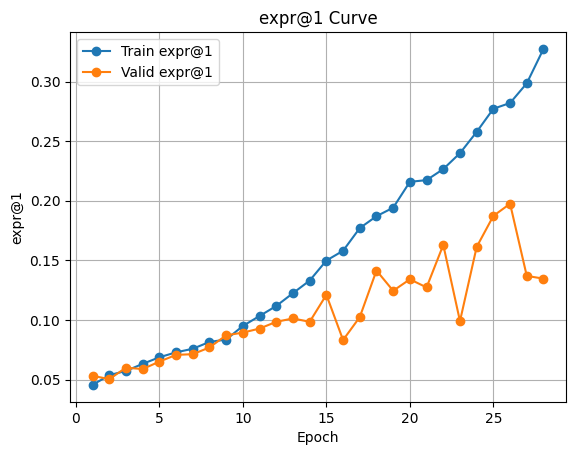

In [77]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

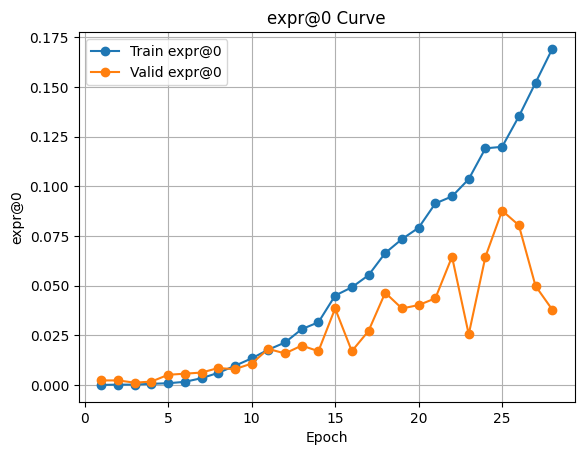

In [78]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

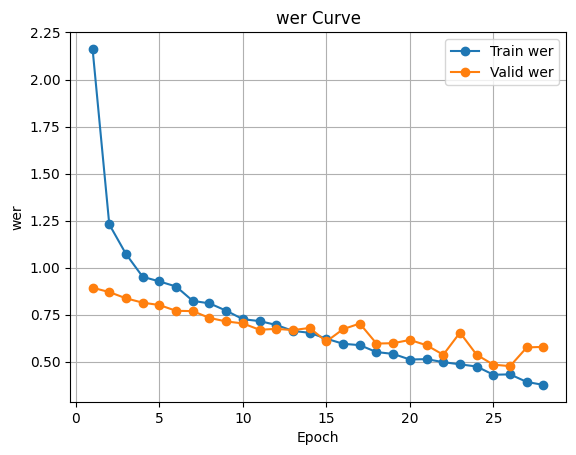

In [79]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

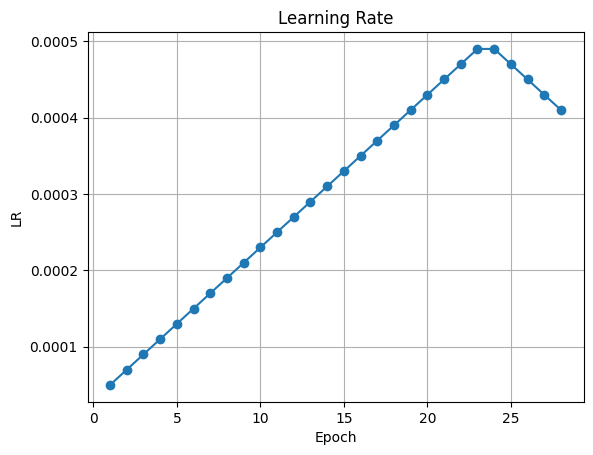

In [80]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [81]:
criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

        expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
        expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
        expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
        expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
        wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

        total_loss += float(loss.item())
        total_expr_0 += expr_0
        total_expr_1 += expr_1
        total_expr_2 += expr_2
        total_expr_3 += expr_3
        total_wer += wer
        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / num_batches
    avg_expr_2 = total_expr_2 / num_batches
    avg_expr_3 = total_expr_3 / num_batches
    avg_wer = total_wer / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [82]:
# best_model.pth 가져오기

model = LiteSATRN().to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

<All keys matched successfully>

In [83]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"loss": [],
            "expr@0": [],
            "expr@1": [],
            "expr@2": [],
            "expr@3": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3, wer = test(model, test_loader, criterion)
    val_dict["loss"].append(loss)
    val_dict["expr@0"].append(expr0)
    val_dict["expr@1"].append(expr1)
    val_dict["expr@2"].append(expr2)
    val_dict["expr@3"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

CROHME_2014


[Test] batch:985/986: 100%|██████████| 986/986 [01:14<00:00, 13.23it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.01, wer=0.76]


CROHME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [01:33<00:00, 12.32it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.66, wer=0.761]


CROHME_2019


...

[Test] batch:1198/1199: 100%|██████████| 1199/1199 [01:32<00:00, 12.99it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=7.55, wer=1.01]


IM2LATEX_HME


[Test] batch:945/946: 100%|██████████| 946/946 [02:38<00:00,  5.96it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=7.96, wer=1]


IM2LATEX_PME


[Test] batch:945/946: 100%|██████████| 946/946 [02:38<00:00,  5.98it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=8.27, wer=1.03]


# Prediction 샘플 시각화

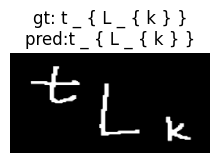

In [99]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

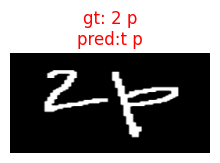

In [85]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

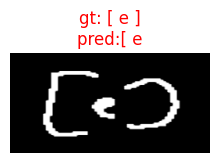

In [86]:
import numpy as np

batch = next(iter(crohme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

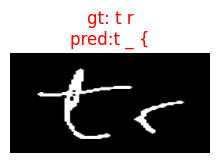

In [87]:
import numpy as np

batch = next(iter(crohme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

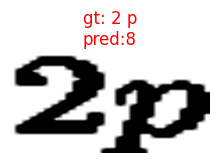

In [88]:
import numpy as np

batch = next(iter(cropme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

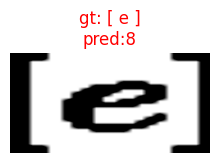

In [89]:
import numpy as np

batch = next(iter(cropme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

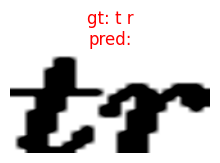

In [90]:
import numpy as np

batch = next(iter(cropme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

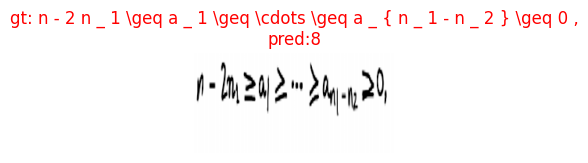

In [91]:
import numpy as np

batch = next(iter(im2latex_hme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

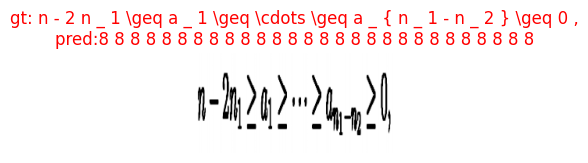

In [92]:
import numpy as np

batch = next(iter(im2latex_pme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)